## 모듈 불러오기

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np
import platform
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, recall_score,precision_score, f1_score, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import optuna
import shap

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [48]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()

KeyboardInterrupt: 

In [ ]:
# 전처리용 데이터프레임 생성
pre = df.copy()

In [ ]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_DI'].dt.year - pre['YoB']

conditions = [
    pre['age'] >= 80,
    pre['age'] >= 70,
    pre['age'] >= 60,
    pre['age'] >= 50,
    pre['age'] >= 40,
    pre['age'] >= 30,
    pre['age'] >= 20
]

choices = ['80+', '70s', '60s', '50s', '40s', '30s', '20s']

pre['age_segment'] = np.select(conditions, choices, default='under 20')

# 결측 따로 처리
pre.loc[pre['age'].isna(), 'age_segment'] = 'unknown'



# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'Certified',
        'Explored',
        'Viewed',
        'Registered'
    ],
    default='None'
)

# 학습 기간 (duration) 컬럼 생성
pre['duration'] = (pre['last_event_DI'] - pre['start_time_DI']).dt.days.astype(int, errors='ignore')


In [ ]:
# 결측치 대체

# 성별 결측치 unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치 unknown 대체
pre['LoE_DI'] = pre['LoE_DI'].fillna('unknown')

# 시용자 행동변수 결측 0으로 대체 : 기록이 안되어있는 값은 interation이 없었기 때문에 결측인 것으로 판단
pre['nevents'] = pre['nevents'].fillna(0)
pre['nplay_video'] = pre['nplay_video'].fillna(0)
pre['ndays_act'] = pre['ndays_act'].fillna(0)
pre['nchapters'] = pre['ndays_act'].fillna(0)

# 성적 결측치 unknown 대체
pre['grade'] = pre['grade'].fillna('unknown')

# last_event_DI 결측값 start_time_DI로 대체
pre['last_event_DI'] = pre['last_event_DI'].fillna(pre['start_time_DI'])

# duration 결측값 0으로 대체
pre['duration'] = pre['duration'].fillna(0)

# incomplete_flag 결측값 0으로 대체
pre['incomplete_flag'] = pre['incomplete_flag'].fillna(0)


In [ ]:
pre['course_id'].value_counts()

course_id
HarvardX/CS50x/2012            169621
MITx/6.00x/2012_Fall            66731
MITx/6.00x/2013_Spring          57715
HarvardX/ER22x/2013_Spring      57406
HarvardX/PH207x/2012_Fall       41592
MITx/6.002x/2012_Fall           40811
HarvardX/PH278x/2013_Spring     39602
MITx/8.02x/2013_Spring          31048
HarvardX/CB22x/2013_Spring      30002
MITx/14.73x/2013_Spring         27870
MITx/6.002x/2013_Spring         22235
MITx/7.00x/2013_Spring          21009
MITx/3.091x/2012_Fall           14215
MITx/8.MReV/2013_Summer          9477
MITx/3.091x/2013_Spring          6139
MITx/2.01x/2013_Spring           5665
Name: count, dtype: int64

In [ ]:
# 행 제거
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] < 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# nchapters가 0인 viewed, explored, certified 행 제거
nchapter_mask = (pre['step'].isin(['Certified', 'Viewed', 'Explored'])) & (pre['nchapters']==0)
pre = pre[~nchapter_mask]

# CS50x 강의 제거
cs50x_mask = (pre['course_id'] =='HarvardX/CS50x/2012')
pre = pre[~cs50x_mask]
print(pre.shape)

(641138, 25)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_480172\3611999105.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


(464552, 25)


In [ ]:
pre['age_segment'].value_counts()

age_segment
20s         234738
unknown      75847
30s          73546
under 20     45765
40s          21037
50s           9282
60s           3593
70s            737
80+              7
Name: count, dtype: int64

In [ ]:
# 컬럼 제거
pre = pre.drop(columns=['index', 'roles', 'YoB', 'registered', 'viewed', 'explored', 'start_time_DI', 'last_event_DI', 'userid_DI', 'age', 'step','grade'])

In [ ]:
# 결측치 개수, 비율
display(pd.DataFrame({
    'bf_sum': df.isna().sum(),
    'bf_ratio': df.isna().mean() * 100,
    'af_sum': pre.isna().sum(),
    'af_ratio': pre.isna().mean() * 100
}).sort_values('bf_ratio', ascending=False).reset_index())

,index,bf_sum,bf_ratio,af_sum,af_ratio
0,roles,641138.0,100.000000,NaN,NaN
1,incomplete_flag,540977.0,84.377622,0.0,0.0
2,nplay_video,457530.0,71.362172,0.0,0.0
3,nchapters,258753.0,40.358394,0.0,0.0
4,nevents,199151.0,31.062111,0.0,0.0
5,last_event_DI,178954.0,27.911932,NaN,NaN
6,ndays_act,162743.0,25.383459,0.0,0.0
7,LoE_DI,106008.0,16.534350,0.0,0.0
8,YoB,96605.0,15.067739,NaN,NaN
9,gender,86806.0,13.539363,0.0,0.0


In [ ]:
# 머러 시작
# test, train 분리
y = pre['certified'].astype(int)
X = pre.drop(columns=['certified']).copy()

# 범주형 컬럼
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
num_cols = X.select_dtypes(include='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [ ]:
# 1. train / valid 분리

# Optuna 내부 평가용 validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

cat_idx_tr = [X_tr.columns.get_loc(col) for col in cat_cols]

# 2. Optuna objective 함수

def objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",   # CatBoost 내부 평가도 PR-AUC 기준
        "random_seed": 42,
        "verbose": 0,
        "auto_class_weights": "Balanced",

        # 튜닝 대상
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "depth": trial.suggest_int("depth", 8, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_tr, y_tr,
        cat_features=cat_idx_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]

    # sklearn PR-AUC
    pr_auc = average_precision_score(y_val, y_val_proba)

    return pr_auc


# 3. Optuna 실행

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n=== Best Trial ===")
print("Best PR-AUC:", study.best_value)
print("Best Params:")
print(study.best_params)


# 4. 최적 파라미터로 전체 train 학습

best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced"
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 5. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

[I 2026-03-23 09:13:27,775] A new study created in memory with name: no-name-4c83dc81-2852-4502-a71f-a23a00cbb00a
Best trial: 0. Best value: 0.89748:   3%|▎         | 1/30 [04:53<2:21:41, 293.15s/it]

[I 2026-03-23 09:18:20,941] Trial 0 finished with value: 0.8974802201003705 and parameters: {'iterations': 961, 'depth': 10, 'learning_rate': 0.04373475873472502, 'l2_leaf_reg': 5.548515503639021, 'min_data_in_leaf': 6, 'subsample': 0.7865915713008728}. Best is trial 0 with value: 0.8974802201003705.


Best trial: 0. Best value: 0.89748:   7%|▋         | 2/30 [12:53<3:08:15, 403.41s/it]

[I 2026-03-23 09:26:21,532] Trial 1 finished with value: 0.896318430305284 and parameters: {'iterations': 887, 'depth': 11, 'learning_rate': 0.01719751742296608, 'l2_leaf_reg': 5.986231576068706, 'min_data_in_leaf': 13, 'subsample': 0.9727029433120984}. Best is trial 0 with value: 0.8974802201003705.


Best trial: 0. Best value: 0.89748:  10%|█         | 3/30 [19:56<3:05:36, 412.45s/it]

...

Best trial: 0. Best value: 0.89748:  37%|███▋      | 11/30 [50:35<1:13:33, 232.30s/it]

[I 2026-03-23 10:04:03,694] Trial 10 finished with value: 0.8959900880893806 and parameters: {'iterations': 586, 'depth': 8, 'learning_rate': 0.09226047615220108, 'l2_leaf_reg': 2.5771441823344343, 'min_data_in_leaf': 1, 'subsample': 0.6001833662264174}. Best is trial 0 with value: 0.8974802201003705.


Best trial: 0. Best value: 0.89748:  37%|███▋      | 11/30 [58:20<1:40:46, 318.26s/it]


[W 2026-03-23 10:11:48,520] Trial 11 failed with parameters: {'iterations': 988, 'depth': 10, 'learning_rate': 0.016301035450866863, 'l2_leaf_reg': 9.215073589496095, 'min_data_in_leaf': 20, 'subsample': 0.870365991101224} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\gmltk\AppData\Local\Temp\ipykernel_480172\372930538.py", line 34, in objective
    model.fit(
  File "c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Proj

KeyboardInterrupt: 

In [ ]:
# 6. 최적 파라미터로 전체 train 학습

# best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    # **best_param,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced",
    max_depth=7,
    iterations=358,
    learning_rate=0.05459690286945743,
    l2_leaf_reg=1.5080143762878997,
    min_data_in_leaf=14,
    subsample=0.9672172477416252
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 7. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test 데이터 모델 성능 ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

0:	learn: 0.9811302	test: 0.9815299	best: 0.9815299 (0)	total: 454ms	remaining: 2m 42s
100:	learn: 0.9950218	test: 0.9947424	best: 0.9947424 (100)	total: 33s	remaining: 1m 23s
200:	learn: 0.9955754	test: 0.9951874	best: 0.9951888 (199)	total: 1m 2s	remaining: 48.8s
300:	learn: 0.9959177	test: 0.9953550	best: 0.9953550 (300)	total: 1m 33s	remaining: 17.8s
357:	learn: 0.9960550	test: 0.9953894	best: 0.9953894 (357)	total: 1m 51s	remaining: 0us

bestTest = 0.995389434
bestIteration = 357


=== Test 데이터 모델 성능 ===
PR-AUC   : 0.8924
ROC-AUC  : 0.9966
Recall   : 0.9898
Precision: 0.5951
F1-score : 0.7433

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9996    0.9764    0.9879     89771
           1     0.5951    0.9898    0.7433      3140

    accuracy                         0.9769     92911
   macro avg     0.7973    0.9831    0.8656     92911
weighted avg     0.9860    0.9769    0.9796     92911


=== Confusion Matrix ===
[[87656  21

In [ ]:
# 1 클래스일 확률
y_proba = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.001)

results = []
best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    precision = precision_score(y_test, y_pred_th, zero_division=0)
    recall = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)

    results.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

result_df = pd.DataFrame(results)

print("최적 threshold:", best_threshold)
print("최적 F1:", best_f1)

display(result_df.sort_values("f1", ascending=False).head(10))

최적 threshold: 0.9440000000000008
최적 F1: 0.8388534085845833


,threshold,precision,recall,f1
894,0.944,0.785973,0.899363,0.838853
885,0.935,0.774481,0.914331,0.838615
893,0.943,0.784466,0.900637,0.838547
884,0.934,0.773620,0.915287,0.838512
886,0.936,0.775372,0.912420,0.838332
892,0.942,0.782009,0.902548,0.837966
895,0.945,0.785834,0.897452,0.837942
887,0.937,0.775848,0.910510,0.837802
883,0.933,0.772373,0.915287,0.837779
897,0.947,0.788586,0.893312,0.837689


In [ ]:
# 적용 후 성능 확인

best_threshold = 0.934
y_pred_opt = (y_proba >= best_threshold).astype(int)


print("=== 최적 threshold 적용 후 성능 ===")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_proba):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_opt):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_opt, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

=== 최적 threshold 적용 후 성능 ===
Threshold : 0.93
Accuracy  : 0.9881
ROC-AUC   : 0.9966
PR-AUC    : 0.8924
Precision : 0.7736
Recall    : 0.9153
F1-score  : 0.8385

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9970    0.9906    0.9938     89771
           1     0.7736    0.9153    0.8385      3140

    accuracy                         0.9881     92911
   macro avg     0.8853    0.9530    0.9162     92911
weighted avg     0.9895    0.9881    0.9886     92911


=== Confusion Matrix ===
[[88930   841]
 [  266  2874]]


<Figure size 1200x700 with 0 Axes>

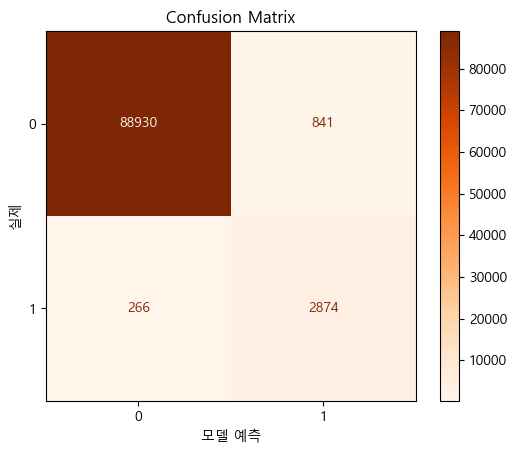

In [ ]:
# 혼동행렬 출력
plt.figure(figsize=(12,7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, cmap='Oranges', values_format="d")
plt.title("Confusion Matrix")
plt.xlabel('모델 예측')
plt.ylabel('실제')
plt.show()

In [ ]:
# shap

# shap explainer 생성
explainer = shap.TreeExplainer(final_model)

# test 데이터에 대한 shap value 계산
shap_values = explainer.shap_values(X_test)

# 이진분류일 때
# 어떤 환경에서는 list가 아니라 바로 array로 나올 수도 있음
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# shop
print(np.array(shap_values_class1).shape)

(92911, 12)


c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


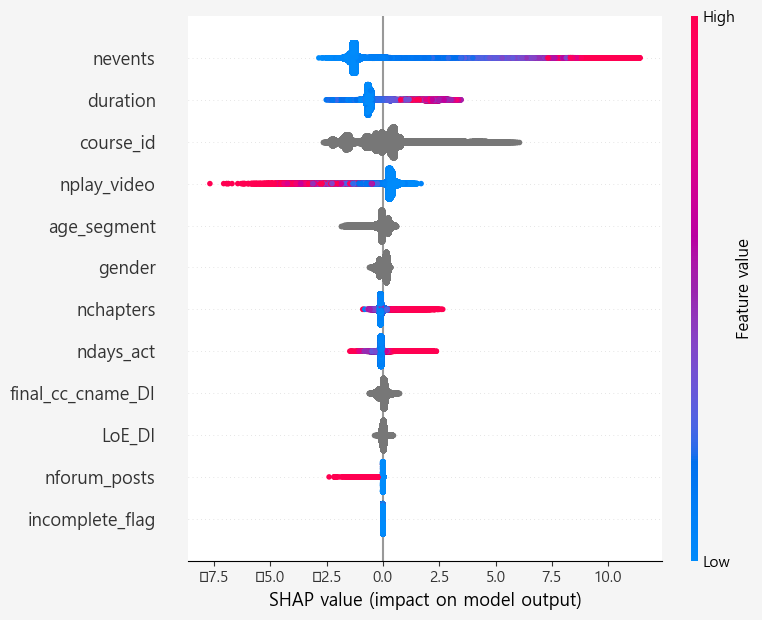

In [ ]:
plt.figure(facecolor='whitesmoke')
shap.summary_plot(shap_values_class1, X_test)

In [ ]:
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

display(shap_importance.head(20))

,feature,mean_abs_shap
4,nevents,2.106589
11,duration,0.911848
0,course_id,0.884127
6,nplay_video,0.633817
10,age_segment,0.183101
3,gender,0.152808
7,nchapters,0.152425
5,ndays_act,0.141323
1,final_cc_cname_DI,0.120563
2,LoE_DI,0.044831
